# **Enriquecimiento de cuentas en Salesforce — Entity resolution con fuentes oficiales (Colombia)**

### **Notebook único — Entrega 1 (CRISP-DM + matching por nombre)**

**Autor:** Juan Pablo Hernández Ortiz  
**Contexto:** Monografía / reto empresarial — calidad de datos en CRM  
**Modelo central (matching por nombre):** TF‑IDF *character n‑grams* + **similitud coseno** (scikit-learn)

# **Descripción del problema (Negocio)**

Salesforce concentra la cartera, pero muchas cuentas quedan sin **NIT**, **CIIU** o **industria/sector**, o con valores inconsistentes. Esto afecta segmentación, reporting y analítica.

**Pregunta operativa:** ¿Cómo identificar la empresa correcta en fuentes oficiales y sugerir/enriquecer campos con trazabilidad y control de riesgo (falsos positivos)?


# **Objetivo del notebook**

- Instalación de dependencias
- Marco CRISP-DM (de negocio a evaluación)
- Explicación y **desglose matemático/computacional** del modelo TF‑IDF usado para matching por nombre
- Demostración reproducible con **datos sintéticos** (no requiere commitear XLSX/CSV reales)
- Analítica: distribución de scores, IDF/nnz a escala, margen top1−top2 y discusión


# ***DESARROLLO***


In [12]:
%pip -q install --upgrade pip
%pip -q install pandas numpy scikit-learn matplotlib seaborn openpyxl pyarrow tqdm


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# **1) Imports y configuración (similar a automobileEDA.ipynb)**

Se agrupan imports por bloques para legibilidad.


In [13]:
# Tratamiento de datos
# ==============================================================================
import os
import textwrap
import numpy as np
import pandas as pd

# Modelado / similitud
# ==============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# **2) Comprensión de datos (CRISP-DM) — qué datos existen y qué riesgos tienen**

## Fuentes (oficiales / públicas)
- **Supersociedades (SIIS)**: carátulas pymes/plenas (NIT + razón social + CIIU, etc.)
- **Datos.gov.co**: *10.000 empresas más grandes de Colombia* (complementa cobertura)
- **Salesforce**: export local de cuentas (NO debe versionarse en GitHub)

## Riesgos de datos
- **PII / confidencialidad** en exports de Salesforce
- **Nombres comerciales** vs **razón social oficial** (no es match exacto por string)
- **Cobertura parcial**: muchas entidades no están en Supersociedades


# **3) Preparación — normalización de texto y NIT (lo esencial)**

Estas funciones son el mismo núcleo conceptual usado en el proyecto: limpiar NIT y normalizar nombre para comparar en el mismo "espacio" que el corpus.


In [14]:
import re
import unicodedata

STOPWORDS = {
    'sas','sa','ltda','cia','compania','compañia',
    'de','la','el','los','las','y','e','en','del',
    'un','una','por','con','para','al','su','sus',
    'colombia','col',
}

def remove_accents(text: str) -> str:
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_company_name(text: str) -> str:
    if text is None or (not isinstance(text, str)):
        return ''
    t = text.lower().strip()
    t = remove_accents(t)
    t = re.sub(r'[^\w\s]', ' ', t)
    tokens = [tok for tok in t.split() if tok not in STOPWORDS and len(tok) > 1]
    return ' '.join(tokens)

def clean_nit(value) -> str | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    s = re.sub(r'[^\d]', '', str(value))
    return s.zfill(9) if s else None


# **4) Modelado — TF‑IDF + coseno: qué es, cómo se construye y por qué sirve para nombres**

## Idea general
Representamos cada nombre normalizado como un vector TF‑IDF en un espacio de **n‑gramas de caracteres** (en vez de palabras). Esto captura:

- sufijos legales (`sas`, `sa`)
- errores de digitación
- variaciones de escritura

## TF (Term Frequency)
Para un término (aquí: un *char n‑gram*) \(t\) en un documento \(d\):

\[
TF(t,d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}
\]

donde \(f_{t,d}\) es la frecuencia del n‑gram en el texto normalizado.

## IDF (Inverse Document Frequency)
Con suavizado (como en sklearn):

\[
IDF(t) = \log\frac{1 + n}{1 + df(t)} + 1
\]

donde \(df(t)\) es el número de documentos del corpus que contienen el término.

## TF‑IDF
\[
TFIDF(t,d) = TF(t,d) \times IDF(t)
\]

## Similitud coseno
Para vectores \(a\) y \(b\):

\[
cos(\theta) = \frac{a \cdot b}{\lVert a \rVert_2 \, \lVert b \rVert_2}
\]

En sklearn, `cosine_similarity` implementa esto de forma eficiente para matrices sparse.

## Hiperparámetros del proyecto (matching por nombre)
- `analyzer='char_wb'` (n‑grams de caracteres con límites de palabra)
- `ngram_range=(2,4)`
- umbral operativo: **0.85** auto, **0.70** revisión (según README del proyecto)


# **5) Demo reproducible (sin datos reales): corpus + consultas + scores**

Reemplazo de construcción de `corpus_df` por lectura real.


In [15]:
# --- Construcción de un mini-corpus sintético (solo para enseñanza) ---
corpus_raw = [
    ('900000001', 'YANBAL DE COLOMBIA SAS'),
    ('900000002', 'ECOPETROL S A'),
    ('900000003', 'PROGAN DEL CARIBE S A S'),
    ('900000004', 'UNIVERSIDAD EAFIT'),
    ('900000005', 'BANCO DE BOGOTA S A'),
    ('900000006', 'ALMACENES EXITO S A'),
    ('900000007', 'GRUPO NUTRESA S A'),
    ('900000008', 'ORGANIZACION CORONA SAS'),
    ('900000009', 'CEMEX COLOMBIA S A'),
    ('900000010', 'POSTOBON S A'),
    ('900000011', 'BAVARIA S A'),
    ('900000012', 'TERPEL S A'),
    ('900000013', 'COLGATE PALMOLIVE COLOMBIA SA'),
    ('900000014', 'IBM COLOMBIA SAS'),
    ('900000015', 'MICROSOFT COLOMBIA SAS'),
    ('900000016', 'NESTLE DE COLOMBIA S A'),
    ('900000017', 'CARULLA VIVERO SA'),
    ('900000018', 'OLIMPICA SAS'),
    ('900000019', 'PIPELINE TECH SAS'),
    ('900000020', 'BANCOLOMBIA S A'),
]

corpus_df = pd.DataFrame(corpus_raw, columns=['nit', 'razon_social'])
corpus_df['razon_social_norm'] = corpus_df['razon_social'].map(normalize_company_name)

queries = pd.DataFrame([
    {'account_name': 'Yanbal Colombia', 'nit': np.nan},
    {'account_name': 'Ecopetrol', 'nit': '900000002'},
    {'account_name': 'Progan Caribe', 'nit': np.nan},
    {'account_name': 'Universidad EAFIT', 'nit': np.nan},
    {'account_name': 'Banco de Bogotá', 'nit': np.nan},
    {'account_name': 'Éxito', 'nit': np.nan},
    {'account_name': 'Nutresa', 'nit': np.nan},
    {'account_name': 'Corona Colombia', 'nit': np.nan},
    {'account_name': 'Cemex Colombia', 'nit': np.nan},
    {'account_name': 'Postobon', 'nit': np.nan},
    {'account_name': 'Bavaria', 'nit': np.nan},
    {'account_name': 'Terpel', 'nit': np.nan},
    {'account_name': 'Colgate Palmolive', 'nit': np.nan},
    {'account_name': 'IBM Colombia', 'nit': np.nan},
    {'account_name': 'Microsoft Colombia', 'nit': np.nan},
    {'account_name': 'Nestlé Colombia', 'nit': np.nan},
    {'account_name': 'Carulla', 'nit': np.nan},
    {'account_name': 'Olímpica', 'nit': np.nan},
    {'account_name': 'Pipeline Tech', 'nit': np.nan},
    {'account_name': 'Bancolombia', 'nit': np.nan},
])

queries['account_name_norm'] = queries['account_name'].map(normalize_company_name)

display(corpus_df.head(20))
display(queries.head(20))


,nit,razon_social,razon_social_norm
0,900000001,YANBAL DE COLOMBIA SAS,yanbal
1,900000002,ECOPETROL S A,ecopetrol
2,900000003,PROGAN DEL CARIBE S A S,progan caribe
3,900000004,UNIVERSIDAD EAFIT,universidad eafit
4,900000005,BANCO DE BOGOTA S A,banco bogota
5,900000006,ALMACENES EXITO S A,almacenes exito
6,900000007,GRUPO NUTRESA S A,grupo nutresa
7,900000008,ORGANIZACION CORONA SAS,organizacion corona
8,900000009,CEMEX COLOMBIA S A,cemex
9,900000010,POSTOBON S A,postobon


,account_name,nit,account_name_norm
0,Yanbal Colombia,NaN,yanbal
1,Ecopetrol,900000002,ecopetrol
2,Progan Caribe,NaN,progan caribe
3,Universidad EAFIT,NaN,universidad eafit
4,Banco de Bogotá,NaN,banco bogota
5,Éxito,NaN,exito
6,Nutresa,NaN,nutresa
7,Corona Colombia,NaN,corona
8,Cemex Colombia,NaN,cemex
9,Postobon,NaN,postobon


Se trabajara con estos datos sin meter al repo datasets sensibles. Por eso la sección de demostración usa un mini-corpus sintético para enseñar cómo se vectoriza, cómo se calcula similitud y cómo se leen métricas como margen y umbrales.

## **5.1) Vectorización TF‑IDF del corpus**

Inspeccionamos dimensionalidad y sparsity.


In [16]:
vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    min_df=1,
    max_features=50_000,
)

X_corpus = vectorizer.fit_transform(corpus_df['razon_social_norm'].fillna(''))
feature_names = np.array(vectorizer.get_feature_names_out())

density = X_corpus.nnz / (X_corpus.shape[0] * X_corpus.shape[1])
print('Corpus TF-IDF shape:', X_corpus.shape)
print('Nonzero entries:', X_corpus.nnz)
print('Density:', round(float(density), 6))


Corpus TF-IDF shape: (20, 479)
Nonzero entries: 601
Density: 0.062735


### **TF‑IDF a escala: discriminación sin matriz documento×término**

Dos vistas que escalan y explican el rol del modelo:

- **IDF alto** en n-gramas: términos **raros** en el corpus (suelen separar mejor candidatos que n-gramas ultra comunes).

- **nnz por fila**: cuántos n-gramas recibe peso > 0 por razón social (complejidad del nombre vs vectorización).


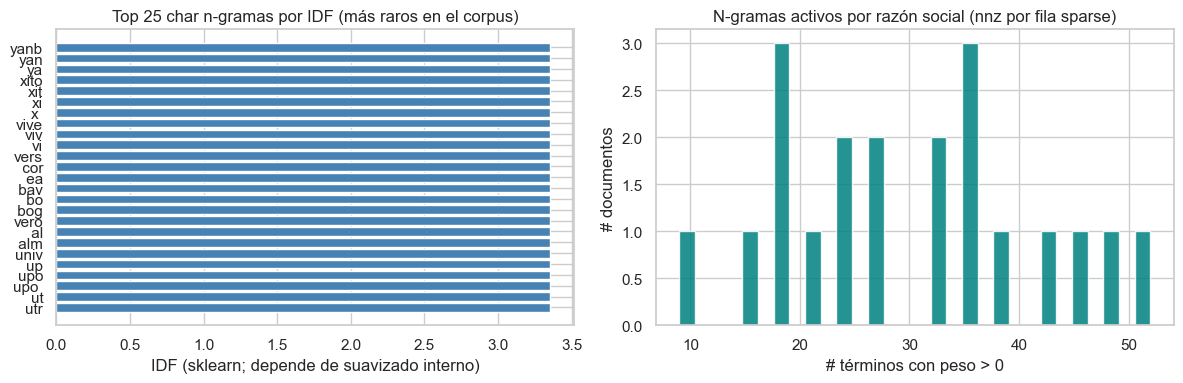

Vocabulario: 479 features
nnz por doc — media: 30.05 | mediana: 29.5 | max: 52


In [17]:
idf = np.asarray(vectorizer.idf_)
top_k = min(25, len(feature_names))
top_idf_idx = np.argsort(-idf)[:top_k]

nnz_per_doc = np.diff(X_corpus.indptr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

terms_top = feature_names[top_idf_idx]
idf_top = idf[top_idf_idx]
axes[0].barh(terms_top[::-1], idf_top[::-1], color='steelblue')
axes[0].set_title(f'Top {top_k} char n-gramas por IDF (más raros en el corpus)')
axes[0].set_xlabel('IDF (sklearn; depende de suavizado interno)')

bins = int(np.clip(nnz_per_doc.max(), 5, 30))
axes[1].hist(nnz_per_doc, bins=bins, edgecolor='white', color='teal', alpha=0.85)
axes[1].set_title('N-gramas activos por razón social (nnz por fila sparse)')
axes[1].set_xlabel('# términos con peso > 0')
axes[1].set_ylabel('# documentos')

plt.tight_layout()
plt.show()

print(f'Vocabulario: {X_corpus.shape[1]:,} features')
print(
    'nnz por doc — media:', round(float(nnz_per_doc.mean()), 2),
    '| mediana:', float(np.median(nnz_per_doc)),
    '| max:', int(nnz_per_doc.max()),
)


Estos gráficos sirven para ilustrar el método; para sacar conclusiones de negocio o de calidad del modelo hay que correrlos sobre un corpus grande (o una muestra representativa) de datos reales.

## **5.2) Matching por nombre: similitud coseno query vs corpus**

Para cada consulta, calculamos similitud contra todo el corpus y tomamos el máximo.


In [18]:
TH_AUTO = 0.85
TH_REV = 0.70

X_q = vectorizer.transform(queries['account_name_norm'].fillna(''))
S = cosine_similarity(X_q, X_corpus)  # shape: (#queries, #corpus)

rows = []
for i, q in queries.iterrows():
    scores = S[i]
    j = int(scores.argmax())
    best = float(scores[j])

    decision = 'no_match'
    if best >= TH_AUTO:
        decision = 'tfidf_auto'
    elif best >= TH_REV:
        decision = 'tfidf_review'

    rows.append({
        'query': q['account_name'],
        'best_match': corpus_df.loc[j, 'razon_social'],
        'best_nit': corpus_df.loc[j, 'nit'],
        'score': round(best, 4),
        'decision': decision,
    })

res = pd.DataFrame(rows)
display(res)


,query,best_match,best_nit,score,decision
0,Yanbal Colombia,YANBAL DE COLOMBIA SAS,900000001,1.0000,tfidf_auto
1,Ecopetrol,ECOPETROL S A,900000002,1.0000,tfidf_auto
2,Progan Caribe,PROGAN DEL CARIBE S A S,900000003,1.0000,tfidf_auto
3,Universidad EAFIT,UNIVERSIDAD EAFIT,900000004,1.0000,tfidf_auto
4,Banco de Bogotá,BANCO DE BOGOTA S A,900000005,1.0000,tfidf_auto
5,Éxito,ALMACENES EXITO S A,900000006,0.5937,no_match
6,Nutresa,GRUPO NUTRESA S A,900000007,0.7623,tfidf_review
7,Corona Colombia,ORGANIZACION CORONA SAS,900000008,0.6036,no_match
8,Cemex Colombia,CEMEX COLOMBIA S A,900000009,1.0000,tfidf_auto
9,Postobon,POSTOBON S A,900000010,1.0000,tfidf_auto


### **Margen y calibración por umbral**

Para entity resolution importa más:

- **Margen (top1 − top2):** si el mejor candidato gana por poco, hay **ambigüedad** (riesgo de falso positivo).
- **Mejor score por query** frente a `TH_AUTO` / `TH_REV`: lectura directa de política de decisión.


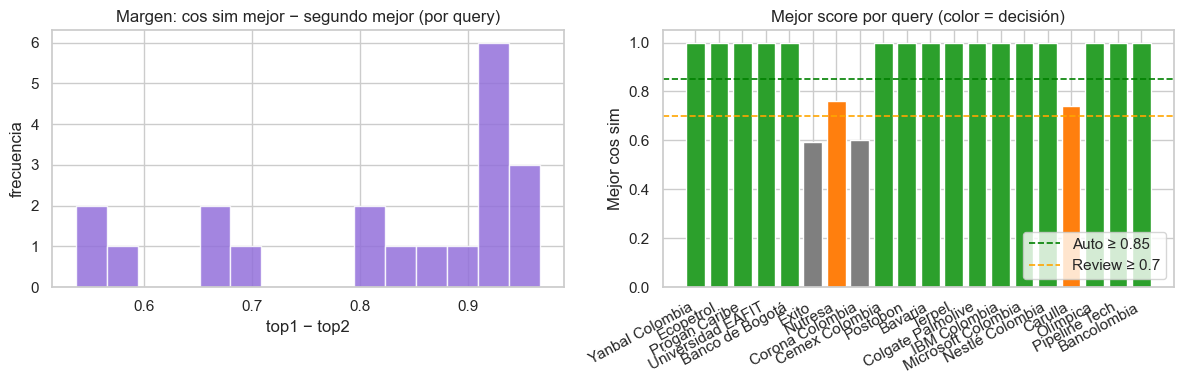

Margen — min: 0.5368 | media: 0.814 | max: 0.967


In [19]:
top1 = S.max(axis=1)
if S.shape[1] >= 2:
    top2 = np.partition(S, -2, axis=1)[:, -2]
else:
    top2 = np.zeros_like(top1)
margin = top1 - top2

palette = {'tfidf_auto': '#2ca02c', 'tfidf_review': '#ff7f0e', 'no_match': '#7f7f7f'}
colors = res['decision'].map(palette)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(margin, bins=min(15, max(5, len(margin) * 2)), edgecolor='white', color='mediumpurple', alpha=0.85)
axes[0].set_title('Margen: cos sim mejor − segundo mejor (por query)')
axes[0].set_xlabel('top1 − top2')
axes[0].set_ylabel('frecuencia')

xpos = np.arange(len(res))
axes[1].bar(xpos, res['score'], color=colors)
axes[1].axhline(TH_AUTO, color='green', linestyle='--', linewidth=1.2, label=f'Auto ≥ {TH_AUTO}')
axes[1].axhline(TH_REV, color='orange', linestyle='--', linewidth=1.2, label=f'Review ≥ {TH_REV}')
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(res['query'], rotation=28, ha='right')
axes[1].set_ylabel('Mejor cos sim')
axes[1].set_title('Mejor score por query (color = decisión)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print('Margen — min:', round(float(margin.min()), 4), '| media:', round(float(margin.mean()), 4), '| max:', round(float(margin.max()), 4))


Con 20 pares “de manual” todo sale casi perfecto. Estos gráficos describen confianza y umbrales y solo cobran sentido de negocio con muchos casos reales.

### **Distribución de scores (demo)**


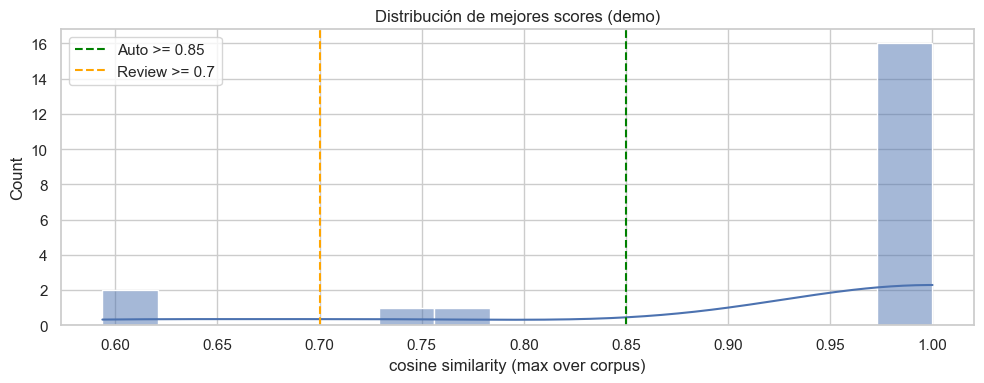

In [20]:
plt.figure(figsize=(10,4))
sns.histplot(res['score'], bins=15, kde=True)
plt.axvline(TH_AUTO, color='green', linestyle='--', label=f'Auto >= {TH_AUTO}')
plt.axvline(TH_REV, color='orange', linestyle='--', label=f'Review >= {TH_REV}')
plt.title('Distribución de mejores scores (demo)')
plt.xlabel('cosine similarity (max over corpus)')
plt.legend()
plt.tight_layout()
plt.show()


Estos registros presentan una similitud $\geq$ 0.85, lo que indica que el nombre entrante y el existente son prácticamente idénticos (ej. "Inversiones ABC S.A.S." vs "Inversiones ABC SAS"). La actualización de la cuenta en el sistema de gestión o CRM puede ejecutarse sin validación manual

## **5.3) Intuición de por qué TF‑IDF “explica” el match**

Para una query, mostramos los **top términos** con mayor TF‑IDF en el documento matched (no es causalidad, pero ayuda a interpretar).


In [21]:
def top_tfidf_terms_for_doc(X_row, terms, topn=12):
    row = X_row.toarray().ravel()
    idx = np.argsort(-row)[:topn]
    out = pd.DataFrame({'term': terms[idx], 'tfidf': row[idx]})
    return out[out['tfidf'] > 0]

example_query = queries.loc[0, 'account_name_norm']
xq = vectorizer.transform([example_query])
scores = cosine_similarity(xq, X_corpus).ravel()
j = int(scores.argmax())

print('Query normalizada:', example_query)
print('Mejor match:', corpus_df.loc[j, 'razon_social'], 'score=', round(float(scores[j]), 4))
display(top_tfidf_terms_for_doc(X_corpus[j], feature_names))


Query normalizada: yanbal
Mejor match: YANBAL DE COLOMBIA SAS score= 1.0


,term,tfidf
0,yanb,0.248161
1,yan,0.248161
2,ya,0.248161
3,nb,0.248161
4,nba,0.248161
5,nbal,0.248161
6,bal,0.248161
7,bal,0.248161
8,al,0.248161
9,y,0.248161


# **6) Evaluación (CRISP-DM) — cómo se evalúa sin “etiquetas perfectas”**

En el proyecto real se combinan:

- **Cobertura** (% cuentas con match auto / revisión / sin match)
- **Distribución de scores** (calibración de umbrales)
- **Consistencia de industria** (coincide / difiere / SF vacío)
- (Fase siguiente) **muestra etiquetada** para precision/recall/F1

## Resultados agregados del avance (piloto real)
Estos números provienen del PDF del avance / ejecución piloto (no incluyen filas sensibles):

- Cuentas únicas: **10,246**
- Auto (NIT exacto + TF‑IDF ≥0.85): **2,164 (21.1%)**
  - NIT exacto: **870 (8.5%)**
  - TF‑IDF auto: **1,294 (12.6%)**
- Revisión manual: **1,399 (13.7%)**
- Sin match: **6,683 (65.2%)**
- Corpus unificado: **30,375** empresas únicas
- Contribución por fuente (solo auto): **10k 73.5%**, **pymes 24.5%**, **plenas 2.0%**
- TF‑IDF auto (n=1,294): min **0.8500**, max **1.0000**, mean **0.9762**


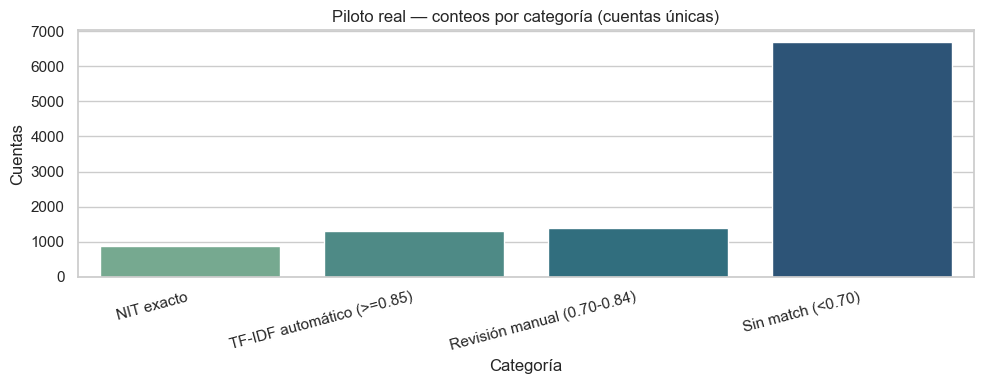

,Categoría,Cuentas,%
0,NIT exacto,870,8.5
1,TF-IDF automático (>=0.85),1294,12.6
2,Revisión manual (0.70-0.84),1399,13.7
3,Sin match (<0.70),6683,65.2


In [22]:
pilot = pd.DataFrame([
    ['NIT exacto', 870, 8.5],
    ['TF-IDF automático (>=0.85)', 1294, 12.6],
    ['Revisión manual (0.70-0.84)', 1399, 13.7],
    ['Sin match (<0.70)', 6683, 65.2],
], columns=['Categoría', 'Cuentas', '%'])

plt.figure(figsize=(10,4))
sns.barplot(data=pilot, x='Categoría', y='Cuentas', palette='crest')
plt.title('Piloto real — conteos por categoría (cuentas únicas)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

display(pilot)


# **7) Despliegue (qué significa en Salesforce) — sin credenciales en el repo**

El despliegue recomendado es:

- generar un archivo enriquecido **local**
- aplicar reglas de gobernanza (llenar vacíos vs sobrescribir)
- escribir a Salesforce vía API usando secretos fuera del repo (GitHub Actions secrets / `.env` local)


# **8) Conclusiones y trabajo futuro**

- TF‑IDF por caracteres es una base sólida para variaciones de nombre, pero no cubre todo el universo.
- La ampliación del corpus (10k) aumenta cobertura por NIT.
- Próximos pasos: RUES, embeddings, muestra etiquetada, escritura gobernada a Salesforce.


# **Referencias (APA sugerida)**

- Datos Abiertos de Colombia. (s. f.). *10.000 empresas más grandes de Colombia* [Conjunto de datos]. `datos.gov.co`.
- Superintendencia de Sociedades. (s. f.). *Información empresarial – Descarga de datos (SIIS)*.
- Salton, G., & McGill, M. J. (1983). *Introduction to modern information retrieval*. McGraw-Hill.
- Chapman et al. (2000). *CRISP-DM 1.0*.
